# Code

## Configuration & General

### Imports

In [1]:
from sklearn import set_config
set_config(transform_output="pandas")

import os
import pandas as pd
import numpy as np
import torch
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from google.colab import drive

# --- CONFIGURATION & GLOBALS ---
drive.mount('content/')
plt.style.use("ggplot")

BASE_DIR = "content/MyDrive/Colab Notebooks/GP Datasets/"
MODELS_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

MAIN_CSV_FILE = "25_countries_main.csv"
MAIN_CSV_PATH = os.path.join(BASE_DIR, MAIN_CSV_FILE)

Mounted at content/


### Loading data

In [7]:
data_df = pd.read_csv(MAIN_CSV_PATH, parse_dates=['date'])

data_df.shape

(14100, 33)

## Feature Selection

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import MultiTaskElasticNetCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

targets = ['respiratory_disease_rate', 'cardio_mortality_rate', 'vector_disease_risk_score', 'waterborne_disease_incidents', 'heat_related_admissions']
HELPER_COLS = ['record_id', 'country_code', 'country_name', 'region', 'income_level', 'date', 'year', 'week']

MISSING_RATIO_THRESHOLD = 0.3
CORR_THRESHOLD = 0.95
ELASTICNET_L1_RATIOS = [0.2, 0.5, 0.8]

RANDOM_STATE = 42

df = data_df.copy()

X = df.drop(columns=targets)
y = df[targets]

X_helpers = X[HELPER_COLS]
X_num = X.drop(columns=HELPER_COLS)

In [ ]:
# ============================================================
# 1. SAFE PRE-FILTERING
# ============================================================

# ---- 1.1 Missing Value Filter
missing_ratio = X_num.isna().mean()
keep_missing = missing_ratio[missing_ratio <= MISSING_RATIO_THRESHOLD].index
X_num = X_num[keep_missing]

# ---- 1.2 Near-Zero Variance Filter
vt = VarianceThreshold(threshold=1e-4)
X_vt = vt.fit_transform(X_num)
vt_features = X_num.columns[vt.get_support()]
X_num = pd.DataFrame(X_vt, columns=vt_features, index=X_num.index)

# ---- 1.3 Extreme Correlation Filter
corr_matrix = X_num.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper.columns if any(upper[col] > CORR_THRESHOLD)]
X_num = X_num.drop(columns=to_drop_corr)

print(f"After pre-filtering: {X_num.shape[1]} features")

After pre-filtering: 17 features


In [ ]:
# ============================================================
# 2. SCALING
# ============================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

In [ ]:
# ============================================================
# 3. MULTI-TASK ELASTIC NET (CORE STEP)
# ============================================================

enet = MultiTaskElasticNetCV(l1_ratio=ELASTICNET_L1_RATIOS, cv=TimeSeriesSplit(n_splits=5), random_state=RANDOM_STATE, max_iter=10000, n_jobs=-1)

enet.fit(X_scaled, y.values)

# ---- Coefficient aggregation across targets
coef_matrix = enet.coef_          # shape: (n_targets, n_features)
coef_norm = np.linalg.norm(coef_matrix, axis=0)

coef_df = (
    pd.DataFrame({'feature': X_num.columns, 'coef_l2_norm': coef_norm})
    .sort_values('coef_l2_norm', ascending=False)
    .reset_index(drop=True)
)

# ---- Threshold: non-zero + percentage
NON_ZERO_THRESHOLD = np.percentile(coef_norm[coef_norm > 0], 15)

selected_elasticnet = coef_df[coef_df['coef_l2_norm'] > NON_ZERO_THRESHOLD]['feature'].tolist()

print(f"ElasticNet selected {len(selected_elasticnet)} features")

ElasticNet selected 12 features


In [ ]:
# ============================================================
# 4. PERMUTATION IMPORTANCE (VALIDATION)
# ============================================================

rf = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)

rf.fit(X_scaled.iloc[:, [X_num.columns.get_loc(f) for f in selected_elasticnet]], y.mean(axis=1))

perm = permutation_importance(
    rf,
    X_scaled.iloc[:, [X_num.columns.get_loc(f) for f in selected_elasticnet]],
    y.mean(axis=1),
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [ ]:
perm_df = (
    pd.DataFrame({'feature': selected_elasticnet, 'perm_importance_mean': perm.importances_mean})
    .sort_values('perm_importance_mean', ascending=False)
    .reset_index(drop=True)
)

# Keep features validated by BOTH
FINAL_THRESHOLD = perm_df['perm_importance_mean'].median()

selected_features_final = perm_df[perm_df['perm_importance_mean'] >= FINAL_THRESHOLD]['feature'].tolist()

print(f"PermutationImportance selected: {len(selected_features_final)} features")

feature_ranking_df = (
    coef_df
    .merge(perm_df, on='feature', how='left')
    .fillna(0)
    .sort_values(['coef_l2_norm', 'perm_importance_mean'], ascending=False)
    .reset_index(drop=True)
)

non_zero_features = feature_ranking_df[
    (feature_ranking_df['coef_l2_norm'] > 0) &
    (feature_ranking_df['perm_importance_mean'] > 0)
]

features = non_zero_features['feature'].tolist()
non_zero_features

PermutationImportance selected: 6 features


,feature,coef_l2_norm,perm_importance_mean
0,temperature_celsius,10.734192,0.903763
1,pm25_ugm3,6.992854,0.171214
2,heat_wave_days,4.641342,0.125423
3,aqi_pm,3.175321,0.141765
4,healthcare_access_index,2.388182,0.080172
5,month,2.008126,0.089628
6,temp_anomaly_celsius,1.974587,0.074409
7,flood_indicator,1.815751,0.005803
8,precipitation_mm,1.549287,0.059812
9,population_millions,0.911221,0.011088


## Skip Feature Selection

In [11]:
features = [
    'temperature_celsius',
    'pm25_ugm3',
    'heat_wave_days',
    'aqi_pm',
    'healthcare_access_index',
    'month',
    'temp_anomaly_celsius',
    'flood_indicator',
    'precipitation_mm',
    'population_millions',
    'latitude',
    'longitude',
]

targets = ['respiratory_disease_rate', 'cardio_mortality_rate', 'vector_disease_risk_score', 'waterborne_disease_incidents', 'heat_related_admissions']

## Data Preparation Helpers

### TimeSeries Splitting

In [9]:
# @title
def ts_fold_split(df, k, min_train_years, val_years, test_years, year_col="year"):
    years = sorted(df[year_col].unique().tolist())

    min_years_needed = min_train_years + val_years + test_years
    assert len(years) >= min_years_needed, (
        f"Not enough unique years ({len(years)}) for "
        f"min_train_years={min_train_years}, "
        f"val_years={val_years}, "
        f"test_years={test_years}"
    )

    max_folds = len(years) - min_years_needed + 1
    k = min(k, max_folds)

    folds = []

    for i in range(k):
        train_end = min_train_years + i
        val_end = train_end + val_years
        test_end = val_end + test_years

        train_years = years[:train_end] # 0-3
        val_years_  = years[train_end:val_end] # 3-4
        test_years_ = years[val_end:test_end] # 4-5

        train_idx = df[df[year_col].isin(train_years)].index.tolist()
        val_idx   = df[df[year_col].isin(val_years_)].index.tolist()
        test_idx  = df[df[year_col].isin(test_years_)].index.tolist()

        if not train_idx or not val_idx or not test_idx:
            continue

        folds.append({
            "train_idx": train_idx,
            "val_idx": val_idx,
            "test_idx": test_idx,

            "train_years": train_years,
            "val_years": val_years_,
            "test_years": test_years_,
        })

    return folds

### Build Folds

In [10]:
def build_folds(df, features, targets, k=5, min_train_years=5, val_years=1, test_years=1):
    folds = []
    folds_info = ts_fold_split(df, k, min_train_years, val_years, test_years)

    for fold in folds_info:
        train_df = df.loc[fold["train_idx"]]
        val_df   = df.loc[fold["val_idx"]]
        test_df  = df.loc[fold["test_idx"]]

        folds.append({
            "X_train": train_df[features], "y_train": train_df[targets],

            "X_val": val_df[features], "y_val": val_df[targets],

            "X_test": test_df[features], "y_test": test_df[targets],

            "train_years": fold["train_years"], "val_years": fold["val_years"], "test_years": fold["test_years"],
        })

    return folds

## Start Training Function

In [12]:
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor

def train_lgbm(fold, **lgbm_params):
    base_model = LGBMRegressor(**lgbm_params)

    model = MultiOutputRegressor(base_model)
    model.fit(fold["X_train"], fold["y_train"])

    return model

In [99]:
lgbm_params = {
    "n_estimators": 600,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": -1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "n_jobs": -1,
}

folds = build_folds(df=data_df, features=features, targets=targets, k=4, min_train_years=2, val_years=3, test_years=3)

models = []

for i, fold in enumerate(folds, 1):
    print(f"Training fold {i} | Train years: {fold['train_years']} | Val years: {fold['val_years']} | Test years: {fold['test_years']}")

    model = train_lgbm(fold, **lgbm_params)
    models.append(model)


Training fold 1 | Train years: [2015, 2016] | Val years: [2017, 2018, 2019] | Test years: [2020, 2021, 2022]
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018529 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1582
[LightGBM] [Info] Number of data points in the train set: 2600, number of used features: 11
[LightGBM] [Info] Start training from score 69.970308
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002498 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1582
[LightGBM] [Info] Number of data points in the train set: 2600, number of used features: 11
[LightGBM] [Info] Start training from score 30.166462
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.031172 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1582
[LightGBM] 

# Testing & Inference

### Testing on the test data loader

In [100]:
def ensemble_predict(models, fold):
    preds = [model.predict(fold['X_test']) for model in models]
    return np.mean(preds, axis=0), np.array(fold['y_test'])

all_preds, all_targets = ensemble_predict(models, folds[-1])

In [112]:
# Alternative baseline

def predict(model, fold):
    return model.predict(fold['X_test']), np.array(fold['y_test'])

all_preds, all_targets = predict(models[-1], folds[-1])

In [113]:
print(all_targets[-5:].tolist())
print(all_preds[-5:].tolist())

[[63.2, 20.2, 0.7, 21.9, 0.0], [83.8, 37.7, 6.2, 19.8, 0.0], [79.1, 31.5, 4.1, 16.2, 0.0], [56.5, 35.7, 11.2, 18.7, 0.0], [58.8, 28.5, 1.6, 15.9, 0.0]]
[[77.15665227566957, 32.069532945051726, 3.456755116697869, 23.785176073355558, -0.138477146590849], [89.76900059101952, 34.61503811109767, 4.11210672525419, 25.126986845398402, 0.06857759124954979], [73.64699012178399, 30.36026748035915, 4.447654824053629, 18.99360272365408, 0.019176146574116683], [50.732496438575986, 27.96039508953008, 4.379503146394793, 21.684826622599427, 0.22777186418308865], [57.25120818035056, 29.63805023306596, 2.876074471128509, 20.225337266483695, 0.020073670317499112]]


In [109]:
# Use these imports when loading via joblib.load
# from lightgbm import LGBMRegressor
# from sklearn.multioutput import MultiOutputRegressor

joblib.dump(models, os.path.join(MODELS_DIR, "[modelling_phase_v5]-lgbm_models.joblib"))

['content/MyDrive/Colab Notebooks/GP Datasets/models/[modelling_phase_v5]-lgbm_models.joblib']

### Calculate metrics per target.

In [114]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    nrmse = rmse / (y_true.max() - y_true.min() + 1e-8)
    return rmse, mae, r2, nrmse

def calculate_metrics(y_true, y_pred, save: bool = False):
    results = {}
    for i, target in enumerate(targets):
        rmse, mae, r2, nrmse = regression_metrics(y_true[:, i], y_pred[:, i])

        results[target] = {"RMSE": rmse, "MAE": mae, "R2": r2, "NRMSE_%": nrmse * 100}

    results_df = pd.DataFrame(results)
    macro_rmse = np.mean([results[t]["RMSE"] for t in targets])

    if save: results_df.to_csv("results.csv")

    return results_df, macro_rmse

results, overall_macro_rmse = calculate_metrics(all_targets, all_preds)

In [115]:
print(f"Overall Macro RMSE: {overall_macro_rmse}")
results

Overall Macro RMSE: 6.14865613334497


,respiratory_disease_rate,cardio_mortality_rate,vector_disease_risk_score,waterborne_disease_incidents,heat_related_admissions
RMSE,10.532689,5.349216,5.605322,5.303097,3.952957
MAE,8.409778,4.243628,3.657323,4.239777,2.522270
R2,0.530033,0.087173,0.896781,0.342653,0.831248
NRMSE_%,10.574989,13.611237,5.605322,8.838496,7.558235


### Visualization & Conclusion

> *Model performance was evaluated using RMSE, MAE, and NRMSE for each health outcome independently to account for scale differences across indicators. RMSE was emphasized due to its sensitivity to extreme health events such as heat-related admissions.*



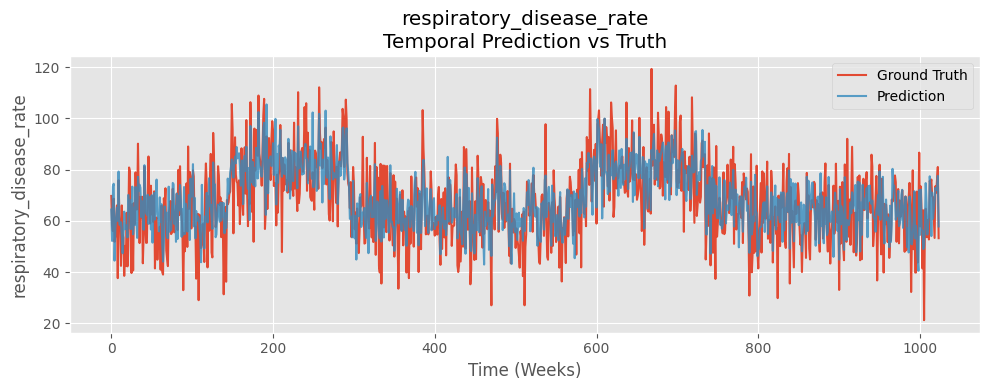

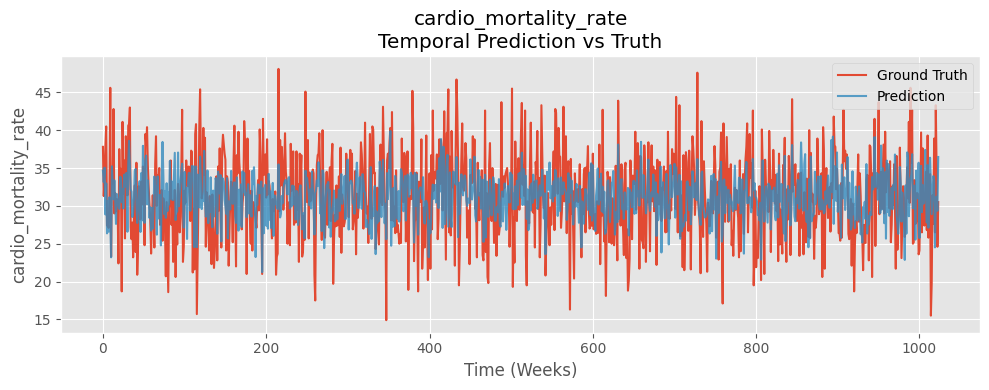

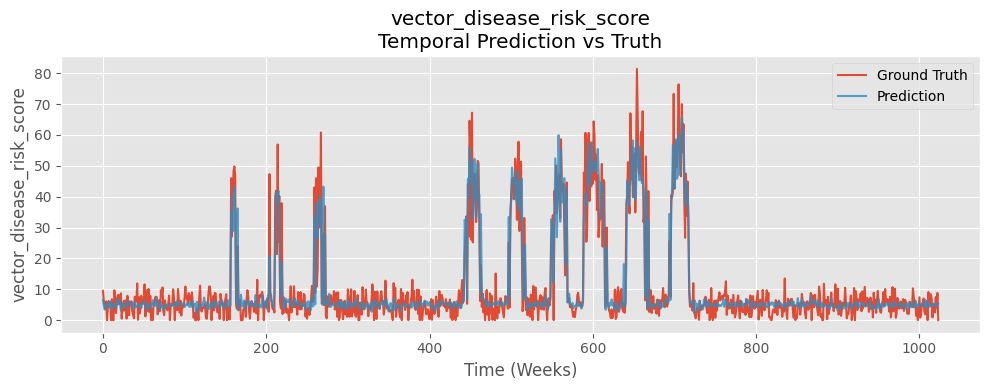

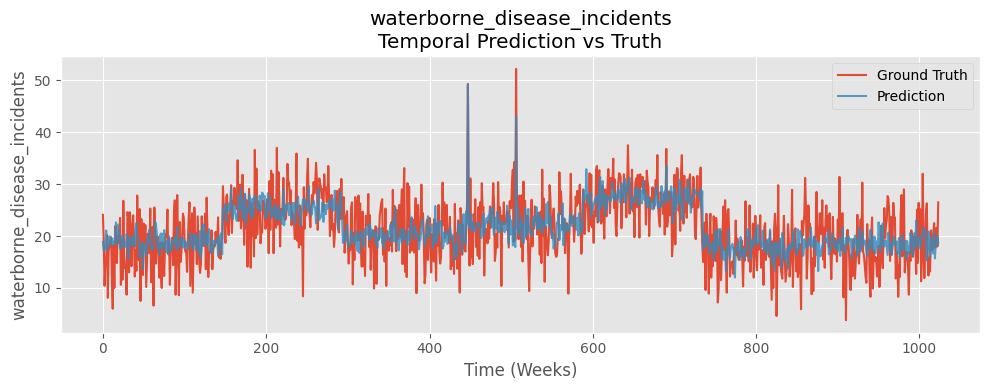

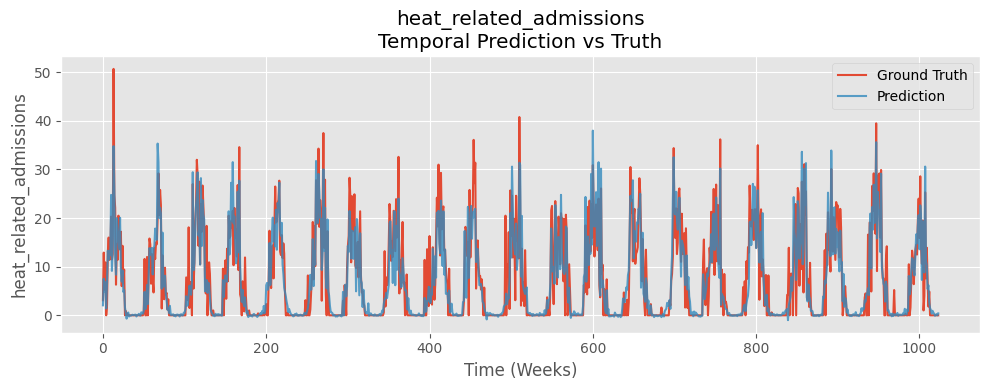

In [108]:
for i, target in enumerate(targets):

    plt.figure(figsize=(10, 4))

    plt.plot(y_true[:1024, i], label="Ground Truth")
    plt.plot(y_pred[:1024, i], label="Prediction", alpha=0.8)

    plt.xlabel("Time (Weeks)")
    plt.ylabel(target)
    plt.title(f"{target}\nTemporal Prediction vs Truth")
    plt.legend()

    plt.tight_layout()
    plt.show()



> *Residual-based visual diagnostics were used to assess model calibration, temporal consistency, and performance under extreme health events. Error dispersion increased during high-magnitude outcomes, highlighting the intrinsic difficulty of forecasting rare public-health spikes.*

